# Making a new domain: `CStarSpecBuilder`

This notebook demonstrates how to create a new domain and run a ROMS simulation using C-SON Forge.


## Setup

First, import the necessary modules and define the domain configuration parameters.


In [8]:
%load_ext autoreload
%autoreload 2

import cson_forge
import cstar.execution.handler as handler
import time
from datetime import datetime
from IPython.display import Markdown, display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import os
os.environ['JUPYTERHUB_SERVICE_PREFIX'] = '/'

from dask.distributed import Client, LocalCluster
cluster = LocalCluster(
    n_workers=16,          # number of worker processes
    threads_per_worker=1, # threads per worker
)

client = Client(cluster)
print(client.dashboard_link)  # e.g. http://127.0.0.1:8787/status

/home/x-uheede/.conda/envs/cson-forge-v0/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36417 instead
  warnings.warn(


/proxy/127.0.0.1:36417/status


2026-03-10 20:40:44,767 [WARNING] - worker_memory.py:430 - Worker tcp://127.0.0.1:42679 (pid=639235) exceeded 95% memory budget. Restarting...
2026-03-10 20:40:44,852 [WARNING] - scheduler.py:5527 - Removing worker 'tcp://127.0.0.1:42679' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('concatenate-open_dataset-vo-original-getitem-e1137e60aa44d4cc002dc2eea5bd0419', 25, 0, 0, 0), ('array-a86d7bb22b639c257e776aa624e64a09', 0, 0)} (stimulus_id='handle-worker-cleanup-1773175244.8524957')
2026-03-10 20:40:44,920 [WARNING] - worker_memory.py:430 - Worker tcp://127.0.0.1:45713 (pid=639278) exceeded 95% memory budget. Restarting...
2026-03-10 20:40:45,017 [WARNING] - scheduler.py:5527 - Removing worker 'tcp://127.0.0.1:45713' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('zeros_like-98629fe3b718f5ef36b5d55a30e1337e', 5, 0, 0, 0), ('zeros_like-ff8165886586b1342ef9fc295fcc9c0f', 23, 0, 0, 0), ('zeros_like-aa6

## Environment and Machine Information

Record the execution environment and machine details for reproducibility.

In [10]:
env = cson_forge.config.get_environment_info()

# Display summary
summary = f"""
### Machine Information
- **Hostname**: `{env.hostname}`
- **System Tag**: `{env.system_tag}`
- **OS**: `{env.os_info}`

### Environment Summary
- **Python Version**: `{env.python_version}`
- **Python Executable**: `{env.python_executable}`
- **Conda/Micromamba Environment**: `{env.env_info}`
- **Kernel**: `{env.kernel_spec}`
"""

display(Markdown(summary))
print(f"Execution timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")



### Machine Information
- **Hostname**: `a058.anvil.rcac.purdue.edu`
- **System Tag**: `RCAC_anvil`
- **OS**: `Linux 4.18.0-553.81.1.el8_10.x86_64 (x86_64)`

### Environment Summary
- **Python Version**: `3.13.11`
- **Python Executable**: `/home/x-uheede/.conda/envs/cson-forge-v0/bin/python`
- **Conda/Micromamba Environment**: `base (/apps/anvil/external/apps/jupyter/2025.07/libexec)`
- **Kernel**: `cson-forge-v0 (ipykernel 7.1.0)`


Execution timestamp: 2026-03-10 15:24:09


In [11]:
grid_name = "Iceland0"
model_name = "cson_roms-marbl_v0.1"
start_time = datetime(2024, 1, 1)
end_time = datetime(2024, 12, 31)

grid_kwargs = dict[str, float](
    nx=512,
    ny=512,
    size_x=1280,
    size_y=1280,
    center_lon=-25,
    center_lat=63,
    rot=-20,
    N=60,  # number of vertical levels
    theta_s=5.0,  # surface control parameter
    theta_b=2.0,  # bottom control parameter
    hc=300.0,  # critical depth
)

boundaries={
        "south": True,
        "east": True,
        "north": True,
        "west": True, 
    }

partitioning = {
    "n_procs_x": 16, # number of partitions in xi (x) 
    "n_procs_y": 16, # number of partitions in eta (y) 
}


## Initialize CstarSpecBuilder

Create a `CstarSpecBuilder` instance with the domain configuration. This initializes the PRECONFIG stage, creating the grid object and blueprint structure.


In [12]:
ocn = cson_forge.CstarSpecBuilder(
    description="Iceland0",
    model_name=model_name,
    grid_name=grid_name,
    grid_kwargs=grid_kwargs,
    open_boundaries=boundaries,    
    start_time=start_time,
    end_time=end_time,
    partitioning=partitioning,
)


### Visualize the grid

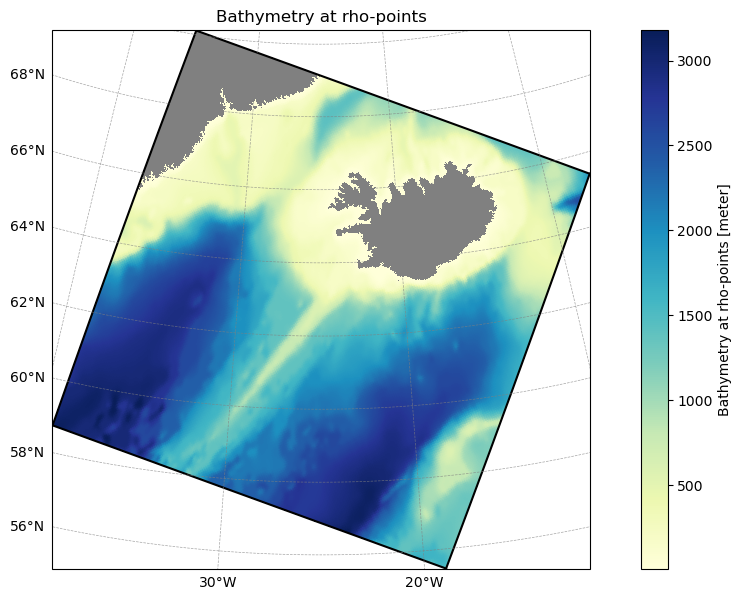

In [13]:
ocn.grid.plot()

## Prepare Source Data

Ensure that all required source datasets (GLORYS, UNIFIED, SRTM15, etc.) are staged locally. This downloads and prepares the data needed for input generation.


## Generate Input Files

Generate all model input files (grid, initial conditions, forcing) from the source data. This completes the POSTCONFIG stage and updates the blueprint with actual file paths.

The system will look for an existing blueprint and, if a match is found, it will use that data unless the user sets `clobber=True` to force re-generating the data. 


In [14]:
# ensure that source data is staged locally
ocn.ensure_source_data()


✔️  Using existing GLORYS_GLOBAL file for 2024-01-01: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240101.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-02: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240102.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-03: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240103.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-04: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240104.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-05: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240105.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-06: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240106.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-07: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240107.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-08: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240108.nc
✔️  Using existing GLORYS_GLOBAL file for 2024-01-09: cmems_mod_glo_phy_my_0.083deg_P1D-m_GLOBAL_20240109.nc
✔️  Using existing 

In [15]:
# prepare model input
ocn.generate_inputs(clobber=True) # setting clobber=True will overwrite existing files


⚠️  Clobber=True: removing 27 existing .nc files in /anvil/projects/x-ees250129/cson-forge-data/x-uheede/input-data/cson_roms-marbl_v0.1_Iceland0_256procs...

▶️  [1/8] Writing ROMS grid...

▶️  [2/8] Generating initial conditions...


2026-03-10 15:24:50,066 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 6.62 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 15:24:50,330 - distributed.worker.memory - WARNING - Worker is at 83% memory usage. Pausing worker.  Process memory: 7.69 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 15:24:50,366 - distributed.worker.memory - WARNING - Worker is at 40% memory usage. Resuming worker. Process memory: 3.71 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 15:24:56,668 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memo


▶️  [3/8] Generating surface forcing...


/home/x-uheede/.conda/envs/cson-forge-v0/lib/python3.13/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 10.61 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/x-uheede/.conda/envs/cson-forge-v0/lib/python3.13/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 23.63 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/x-uheede/.conda/envs/cson-forge-v0/lib/python3.13/site-packages/distributed/client.py:3375: UserWarning: Sending large graph


▶️  [4/8] Generating surface forcing...


2026-03-10 20:38:38,079 [WARNING] - utils.py:109 - Optional variables missing (but not critical): ['pco2_air_alt']



▶️  [5/8] Generating boundary forcing...


2026-03-10 16:39:09,962 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 6.58 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 16:39:09,971 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 6.79 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 16:39:10,443 - distributed.worker.memory - WARNING - Worker is at 84% memory usage. Pausing worker.  Process memory: 7.85 GiB -- Worker memory limit: 9.26 GiB
2026-03-10 16:39:10,470 - distributed.worker.memory - WARNING - Worker is at 45% memory usage. Resuming worker. Process memo

KilledWorker: Attempted to run task ('concatenate-open_dataset-uo-original-getitem-3bbd3acf7fd50bd892aea4b4e778cdda', 26, 0, 0, 0) on 4 different workers, but all those workers died while running it. The last worker that attempt to run the task was tcp://127.0.0.1:45501. Inspecting worker logs is often a good next step to diagnose what went wrong. For more information see https://distributed.dask.org/en/stable/killed.html.

## Access Generated Input Datasets

Input datasets are available on the `datasets` attribute of the `CstarSpecBuilder` after `generate_inputs()` has completed. The `datasets` dictionary only contains keys for fields that exist in the blueprint and have been successfully generated.

**Note:** Datasets are only available after `generate_inputs()` has run and populated the blueprint with actual file paths. If a key doesn't exist, it means that field wasn't generated or isn't in the blueprint.

In [ ]:
for key in ocn.datasets.keys():
    print("-"*100)
    print(key)
    print(ocn.datasets[key])

## Configure Build

Render the Jinja2 templates to generate compile-time and run-time configuration files (`.opt` files, `roms.in`, etc.). This prepares the BUILD stage.


In [ ]:
# configure and build the model
ocn.configure_build(compile_time_settings={}, run_time_settings={})


## Build Model Executable

Compile the ROMS/MARBL model source code to create the executable. This uses the C-Star build system to compile the model with the specified configuration.


In [ ]:
ocn.build()


## Pre-Run Setup

Perform pre-run operations, including partitioning input files for parallel execution if needed.


In [ ]:
# perform partitioning
ocn.pre_run()


## Run Model Simulation

Execute the ROMS model simulation. This runs the model with the configured inputs and settings.


In [ ]:
# run the model
exec_handler = ocn.run()
print(exec_handler)


In [ ]:
%%time

while not handler.ExecutionStatus.is_terminal(exec_handler.status):
    print("...", end="", flush=True)
    time.sleep(30)

if exec_handler.status == handler.ExecutionStatus.COMPLETED:
    print()
    print("Completed")
    ocn.post_run()
else:
    raise Exception("Model run failed")

## Visualize Model Output

After the model run completes, you can load and visualize the output data. The code below:

1. **Finds output files**: Uses `glob` to locate all BGC (biogeochemical) output files in the `JOINED_OUTPUT` directory
2. **Opens the dataset**: Uses `xarray.open_mfdataset()` to open multiple NetCDF files as a single dataset
3. **Applies land mask**: Masks out land points using the grid's `mask_rho` variable
4. **Plots a variable**: Creates a plot of dissolved inorganic carbon (DIC) at the first time step and bottom vertical level (`s_rho=-1`)

The `JOINED_OUTPUT` directory contains the spatially-joined output files created by `post_run()`, which combine partitioned output files from parallel runs into single files.

In [ ]:
str(ocn.run_output_dir / "output" / "joined_output" / (ocn.casename + "_bgc.*"))

In [ ]:
import xarray as xr
from glob import glob

files = glob(str(ocn.run_output_dir / "output" / "joined_output" / ("output_bgc.*")))
ds = xr.open_mfdataset(files)
ds = ds.where(ocn.grid.ds.mask_rho)
ds.DIC.isel(time=0, s_rho=-1).plot()

## Set Blueprint State

The `set_blueprint_state()` method updates the state of the blueprint, which tracks the workflow stage of the simulation specification. Blueprint states indicate the current stage of the workflow (e.g., "draft", "configured", "ready") and are used by the C-Star orchestration system to manage the simulation lifecycle.

Common blueprint states include:
- `"draft"`: The blueprint is in development and not yet finalized
- `"validated"`: The blueprint has been validated

Setting the state to `"draft"` is useful when you want to mark the blueprint as a work-in-progress that may need further modifications before execution.

In [ ]:
ocn.set_blueprint_state(state="draft")

## Save Executed Notebook

Save a timestamped copy of this notebook to `executed/forge/{os}/` for reproducibility and record-keeping. The copy is organized by operating system (macOS or Ubuntu/Linux) to track execution history across different platforms.

The saved notebook includes all executed cells and outputs, providing a complete record of the simulation workflow for future reference.

In [ ]:
# Save the notebook copy
cson_forge.save_notebook_copy(notebook_name="CStarSpecBuilder-demo.ipynb")